In [8]:
import torch.nn as nn
from PIL import Image
import torch.nn.functional as F
from google.colab import files
import matplotlib.pyplot as plt
import io
import os
import shutil
import torch
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import copy
from tqdm import tqdm

In [1]:
# 원본 데이터 경로와 새롭게 만들 이진 분류 데이터 경로 설정
original_dir = r'/content/drive/MyDrive/DeepLearning/dataset/affectNet'
binary_dir = r'/content/drive/MyDrive/DeepLearning/dataset/interest_dataset'

# 감정 매핑 딕셔너리 (데이터셋 폴더명에 맞게 설정)
# 흥미 있음: 행복(happy), 놀람(surprise), 중립(neutral)
# 흥미 없음: 분노(anger), 경멸(contempt), 혐오(disgust), 두려움(fear), 슬픔(sad)
emotion_mapping = {
    'happy': 'interested',
    'surprise': 'interested',
    'neutral': 'interested',
    'anger': 'not_interested',
    'contempt': 'not_interested',
    'disgust': 'not_interested',
    'fear': 'not_interested',
    'sad': 'not_interested'
}

# 새로운 디렉토리 구조 생성 (train, val 각각에 대해)
for phase in ['train', 'val']:
    for new_class in ['interested', 'not_interested']:
        os.makedirs(os.path.join(binary_dir, phase, new_class), exist_ok=True)

# 파일 복사 함수
def copy_files(phase):
    phase_dir = os.path.join(original_dir, phase)
    # 원본 데이터의 train/val 폴더 내 감정 폴더들 순회
    for emotion_folder in os.listdir(phase_dir):
        # 매핑 딕셔너리에 있는 감정인지 확인
        if emotion_folder in emotion_mapping:
            target_class = emotion_mapping[emotion_folder]
            source_folder = os.path.join(phase_dir, emotion_folder)
            target_folder = os.path.join(binary_dir, phase, target_class)

            files = os.listdir(source_folder)
            for file_name in tqdm(files, desc=f"{phase} - {emotion_folder} -> {target_class} 복사 중"):
                source_file = os.path.join(source_folder, file_name)
                # 파일 이름 충돌 방지를 위해 원래 감정 이름을 파일명 앞에 붙임
                target_file = os.path.join(target_folder, f"{emotion_folder}_{file_name}")
                shutil.copy(source_file, target_file)

print("전처리 시작...")
# copy_files('train')
copy_files('val')
print("데이터 전처리 및 이동이 완료되었습니다!")

전처리 시작...


train - surprise -> interested 복사 중: 100%|██████████| 2119/2119 [00:49<00:00, 42.43it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DeepLearning/dataset/affectNet/val'

In [2]:
copy_files('val')

val - contempt -> not_interested 복사 중: 100%|██████████| 1312/1312 [00:31<00:00, 41.88it/s]


In [5]:
# 1. 환경 및 디바이스 설정 (코랩 GPU 할당)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# 전처리된 데이터 경로
data_dir = r'/content/drive/MyDrive/DeepLearning/dataset/interest_dataset'

# 2. 데이터 전처리 (Transforms)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. 데이터셋 로드
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# 코랩 환경 안정성을 위해 num_workers=2로 설정
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
               for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print(f"분류 클래스: {class_names}")

# 4. 데이터 불균형 해결을 위한 클래스 가중치 계산
train_labels = image_datasets['train'].targets
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"적용된 클래스 가중치: {weights_tensor}")

# 5. 전이학습 모델 정의 (ResNet50)
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

def train_model(model, criterion, optimizer, scheduler, num_epochs=50, patience=5):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_acc = 0.0
    epochs_no_improve = 0

    # 🌟 그래프를 그리기 위해 매 에폭의 결과값을 저장할 딕셔너리 생성
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} 진행 중"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            # 텐서 타입인 정확도를 일반 float 숫자로 변환
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 🌟 현재 에폭의 Loss와 Acc를 history에 저장
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

            # 조기 종료 및 최고 성능 모델 저장
            if phase == 'val':
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"🌟 검증 Loss가 {best_loss:.4f}로 개선되어 모델을 저장합니다.")
                else:
                    epochs_no_improve += 1
                    print(f"⚠️ 성능 개선 없음 (연속 {epochs_no_improve}번 / 최대 허용 {patience}번)")

        if epochs_no_improve >= patience:
            print(f'\n🛑 조기 종료 발동! {epoch+1}번째 에폭에서 학습을 멈춥니다.')
            break

    print(f'\n🏆 최고 검증 정확도(Best val Acc): {best_acc:.4f} (Loss: {best_loss:.4f})')

    model.load_state_dict(best_model_wts)

    # 🌟 모델과 함께 기록(history)도 반환하도록 수정
    return model, history


# --- 학습 실행 및 그래프 그리기 ---
print("\n본격적인 모델 학습을 시작합니다!")
# trained_model과 함께 history 정보도 받아옵니다.
trained_model, training_history = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=30, patience=5)

# 최적의 모델 저장
torch.save(trained_model.state_dict(), 'interest_classifier_best.pth')
print("\n학습 완료! 모델이 'interest_classifier_colab.pth' 이름으로 저장되었습니다.")

사용 중인 디바이스: cuda:0
분류 클래스: ['interested', 'not_interested']
적용된 클래스 가중치: tensor([1.1160, 0.9059], device='cuda:0')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



본격적인 모델 학습을 시작합니다!

Epoch 1/80
----------


train 진행 중: 100%|██████████| 504/504 [04:00<00:00,  2.09it/s]


train Loss: 0.3040 Acc: 0.8626


...

val Loss: 0.3234 Acc: 0.9098
⚠️ 성능 개선 없음 (연속 4번 / 최대 허용 5번)

Epoch 7/80
----------


train 진행 중: 100%|██████████| 504/504 [03:16<00:00,  2.56it/s]


train Loss: 0.1602 Acc: 0.9352


val 진행 중: 100%|██████████| 454/454 [00:54<00:00,  8.41it/s]


val Loss: 0.3630 Acc: 0.9024
⚠️ 성능 개선 없음 (연속 5번 / 최대 허용 5번)

🛑 조기 종료 발동! 7번째 에폭에서 학습을 멈춥니다.

🏆 최고 검증 정확도(Best val Acc): 0.9050 (Loss: 0.2785)

학습 완료! 모델이 'interest_classifier_colab.pth' 이름으로 저장되었습니다.


In [ ]:
# ==========================================
# 📈 학습 결과 그래프 시각화 (Loss & Accuracy)
# ==========================================
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # 1. Loss 그래프 그리기
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy 그래프 그리기
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 그리기 함수 호출
plot_history(training_history)

In [6]:
# 1. 설정 및 모델 준비
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
class_names = ['interested', 'not_interested'] # 훈련 시 폴더명 알파벳 순서와 동일해야 함

# 전처리(Transforms) 적용
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 모델 생성 후 저장된 가중치 불러오기 (저장했던 파일명에 맞게 수정하세요)
model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
# 만약 이전 단계에서 조기 종료 모델로 저장했다면 'interest_classifier_best_early_stopped.pth' 로 변경하세요.
model.load_state_dict(torch.load('interest_classifier_colab.pth', map_location=device))
model = model.to(device)
model.eval() # 평가 모드

# 2. 이미지 경로로 예측하는 함수 정의 (수정됨)
def predict_image_by_path(image_path, model, transforms, class_names):
    if not os.path.exists(image_path):
        print(f"❌ 오류: '{image_path}' 경로에 파일이 없습니다. 경로를 다시 확인해주세요.")
        return

    # 이미지 경로에서 바로 열기
    image = Image.open(image_path).convert('RGB')

    # 전처리 및 텐서 변환
    image_tensor = transforms(image).unsqueeze(0).to(device)

    # 예측 수행
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, preds = torch.max(probs, 1)

    predicted_class = class_names[preds[0]]
    confidence_score = confidence[0].item() * 100

    # 결과 시각화
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class} ({confidence_score:.2f}%)")
    plt.show()



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


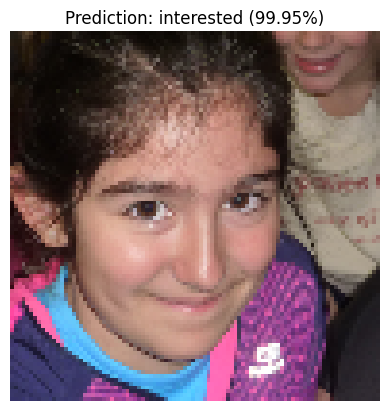

In [10]:
sample_image_path = '/content/drive/MyDrive/DeepLearning/dataset/interest_dataset/val/interested/happy_ffhq_1010.png' # ⬅️ 여기에 테스트할 이미지 경로 입력!

predict_image_by_path(sample_image_path, model, test_transforms, class_names)

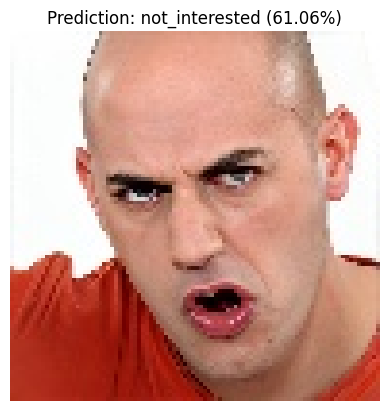

In [19]:
sample_image_path = '/content/drive/MyDrive/DeepLearning/dataset/interest_dataset/val/not_interested/anger_image0010473.jpg' # ⬅️ 여기에 테스트할 이미지 경로 입력!

predict_image_by_path(sample_image_path, model, test_transforms, class_names)

In [12]:
torch.save(trained_model.state_dict(), '/content/drive/MyDrive/DeepLearning/dataset/out/interest_classifier_best.pth')